In [1]:
!pip install nltk scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\mansi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
!pip install wordcloud matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\mansi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mansi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mansi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mansi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mansi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Tokens:
 ['Text', 'analytics', 'is', 'the', 'process', 'of', 'analyzing', 'text', 'data', '.', 'It', 'involves', 'tokenization', ',', 'removing', 'stopwords', ',', 'stemming', ',', 'and', 'lemmatization', '.']
POS Tags:
 [('Text', 'NN'), ('analytics', 'NNS'), ('is', 'VBZ'), ('the', 'DT'), ('process', 'NN'), ('of', 'IN'), ('analyzing', 'VBG'), ('text', 'JJ'), ('data', 'NNS'), ('.', '.'), ('It', 'PRP'), ('involves', 'VBZ'), ('tokenization', 'NN'), (',', ','), ('removing', 'VBG'), ('stopwords', 'NNS'), (',', ','), ('stemming', 'VBG'), (',', ','), ('and', 'CC'), ('lemmatization', 'NN'), ('.', '.')]
After Stopword Removal:
 ['Text', 'analytics', 'process', 'analyzing', 'text', 'data', '.', 'involves', 'tokenization', ',', 'removing', 'stopwords', ',', 'stemming', ',', 'lemmatization', '.']
Stemmed Words:
 ['text', 'analyt', 'process', 'analyz', 'text', 'data', '.', 'involv', 'token', ',', 'remov', 'stopword', ',', 'stem', ',', 'lemmat', '.']
Lemmatized Words:
 ['Text', 'analytics', 'process

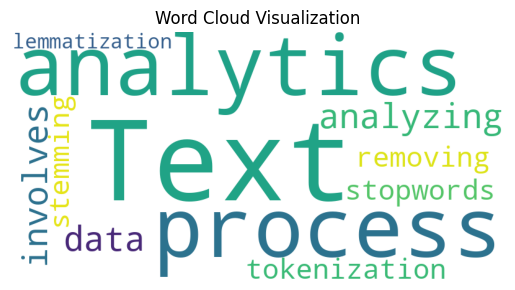

In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

text = """Text analytics is the process of analyzing text data. 
It involves tokenization, removing stopwords, stemming, and lemmatization."""

#Tokenization
tokens = word_tokenize(text)
print("Tokens:\n", tokens)

#POS Tagging
pos = pos_tag(tokens)
print("POS Tags:\n", pos)

#Stopwrods removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
print("After Stopword Removal:\n", filtered_tokens)

#Stemming
ps = PorterStemmer()
stemmed = [ps.stem(word) for word in filtered_tokens]
print("Stemmed Words:\n", stemmed)

#Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print("Lemmatized Words:\n", lemmatized)

#Part-2
#Create Documents
documents = [
    "Text analytics is important",
    "Text mining and text analytics",
    "Analytics includes preprocessing of text"
]

#Term Frequency
cv = CountVectorizer()
tf_matrix = cv.fit_transform(documents)

print("Term Frequency Matrix:\n")
print(tf_matrix.toarray())

print("\nWords:\n", cv.get_feature_names_out())

#TF-IDF Calculation
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)

print("TF-IDF Matrix:\n")
print(tfidf_matrix.toarray())

print("\nWords:\n", tfidf.get_feature_names_out())

#wordcloud
clean_text = " ".join(filtered_tokens)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(clean_text)

plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud Visualization")
plt.show()